## Упражнения  

1. Выбрать и скачать один из наборов данных с сайта [timeseriesclassification](https://www.timeseriesclassification.com/dataset.php).

    Подробнее о датасетах, их форматах, и как их скачивать - [Ноутбук](https://github.com/aeon-toolkit/aeon/blob/main/examples/datasets/data_loading.ipynb)

2.  Записать название выбранного датасета в таблицу. Помните - совпадений быть не должно. Каждый работает с уникальным датасетом. Этот датасет вам понадобиться в лабе 14 (aeon) и лабе 16 (tslean)

3. Проанализировать датасет

4. Найти шейплеты для классов в датесете

5. Провести классификацию на основе шейплетов.

In [9]:
!pip install aeon==0.11.0
!mkdir -p data
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSC_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSC_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSER_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSER_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSER_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSER_TEST.ts -P data/

  Using cached aeon-0.11.0-py3-none-any.whl.metadata (17 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.0.3.tar.gz (5.3 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
File ‘data/KDD_MTSC_TRAIN.ts’ already there; not retrieving.

File ‘data/KDD_MTSC_TEST.ts’ already there; not retrieving.

File ‘data/KDD_UTSC_TRAIN.ts’ already 

In [12]:
!pip install --upgrade pip setuptools wheel

!pip install aeon

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.3 MB/s eta 0:00:00
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 22.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [aeon]ERROR: Operation cancelled by user
Traceback (most recent call last):
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [aeon]^C


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aeon.datasets import load_classification
from aeon.classification.shapelet_based import ShapeletTransformClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score

In [2]:
dataset_name = "ECG200"
print(f"--- Шаг 1-2: Загрузка датасета {dataset_name} ---")

X_train, y_train = load_classification(dataset_name, split="train")
X_test, y_test = load_classification(dataset_name, split="test")

y_train = y_train.astype(int)
y_test = y_test.astype(int)


--- Шаг 1-2: Загрузка датасета ECG200 ---


/tmp/ipykernel_7828/63715950.py:4: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_7828/63715950.py:5: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")


In [3]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
unique_classes = np.unique(y_train)
print(f"Классы в датасете: {unique_classes}")
print(f"Длина одного временного ряда: {X_train.shape[-1]} точек")


Размер обучающей выборки: (100, 1, 96)
Размер тестовой выборки: (100, 1, 96)
Классы в датасете: [-1  1]
Длина одного временного ряда: 96 точек


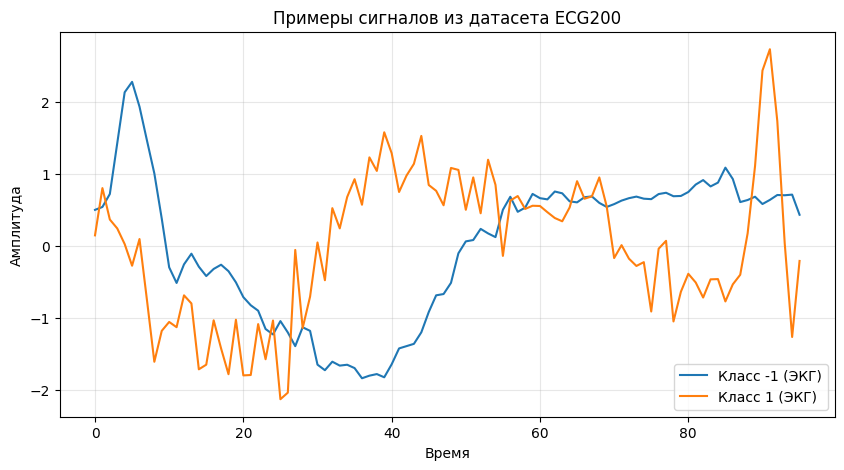

In [4]:
plt.figure(figsize=(10, 5))
for label in unique_classes:
    idx = np.where(y_train == label)[0][0]
    plt.plot(X_train[idx][0], label=f"Класс {label} (ЭКГ)")
plt.title(f"Примеры сигналов из датасета {dataset_name}")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
stc = ShapeletTransformClassifier(
    estimator=RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)),
    max_shapelets=50,
    random_state=42
)

stc.fit(X_train, y_train)
y_pred = stc.predict(X_test)

In [22]:
acc = accuracy_score(y_test, y_pred)
print(f"Точность (Accuracy) модели на основе шейплетов: {acc:.4f}")

Точность (Accuracy) модели на основе шейплетов: 0.8400


In [24]:
shapelets_data = stc._transformer.shapelets
n_shapelets = len(shapelets_data)
print(f"Всего найдено шейплетов: {n_shapelets}")


Всего найдено шейплетов: 47


In [25]:
if n_shapelets > 0:
    first_sh = shapelets_data[0]

    array_found = False
    for i, item in enumerate(first_sh):
        if isinstance(item, (np.ndarray, list)):
            length = len(item)
            print(f"Шейплет найден в индексе [{i}], его длина: {length} точек")
            array_found = True
            break

    if not array_found:
        length_val = first_sh[1]
        print(f"Длина самого характерного шейплета (из метаданных): {length_val} точек")

    print(f"Полная структура данных первого шейплета: {first_sh}")


Шейплет найден в индексе [6], его длина: 88 точек
Полная структура данных первого шейплета: (0.52587597, 88, 7, 0, 82, np.int64(1), array([ 7.69050140e-02,  8.72628399e-01,  5.12413731e-01,  6.22625661e-01,
        6.29812635e-01,  5.45793372e-01,  1.17354753e-01, -6.84192440e-01,
       -9.37925686e-01, -4.52907165e-01, -8.91070377e-01, -9.26317932e-01,
       -9.94162947e-01, -1.39671715e+00, -1.15531282e+00, -1.42100953e+00,
       -1.43242298e+00, -1.67925926e+00, -1.84648638e+00, -1.69820888e+00,
       -2.40236596e+00, -1.88287933e+00, -2.00514165e+00, -2.20273158e+00,
       -1.99396469e+00, -2.46522169e+00, -1.57617459e+00, -1.21893047e+00,
       -1.55550444e+00, -1.07336345e+00, -3.78843672e-01,  4.94311319e-02,
        3.26529477e-02,  6.76632343e-01,  8.51447298e-01,  9.99948432e-01,
        1.24828150e+00,  1.34499040e+00,  1.42129014e+00,  1.27134809e+00,
        1.34939054e+00,  1.18857341e+00,  1.22200108e+00,  1.15703412e+00,
        8.22579322e-01,  1.02084609e+00,  9


Детальный отчет:
              precision    recall  f1-score   support

          -1       0.81      0.72      0.76        36
           1       0.85      0.91      0.88        64

    accuracy                           0.84       100
   macro avg       0.83      0.81      0.82       100
weighted avg       0.84      0.84      0.84       100



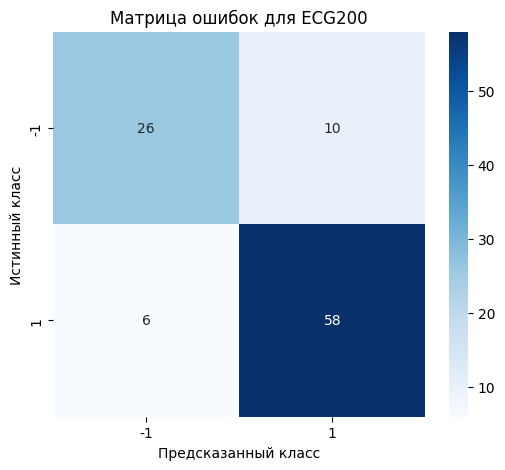

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print("\nДетальный отчет:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))
plt.title(f"Матрица ошибок для {dataset_name}")
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()
